In [1]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
import osmnx as ox

import warnings
warnings.filterwarnings('ignore')


%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
pip show shapely

Name: Shapely
Version: 1.8.5.post1
Summary: Geometric objects, predicates, and operations
Home-page: https://github.com/shapely/shapely
Author: Sean Gillies
Author-email: sean.gillies@gmail.com
License: BSD
Location: /home/mijka/.pyenv/versions/3.8.12/envs/lewagon_current/lib/python3.8/site-packages
Requires: 
Required-by: geopandas, osmnx
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip show osmnx

Name: osmnx
Version: 1.2.2
Summary: Retrieve, model, analyze, and visualize OpenStreetMap street networks and other spatial data
Home-page: https://github.com/gboeing/osmnx
Author: Geoff Boeing
Author-email: boeing@usc.edu
License: MIT
Location: /home/mijka/.pyenv/versions/3.8.12/envs/lewagon_current/lib/python3.8/site-packages
Requires: geopandas, matplotlib, networkx, numpy, pandas, pyproj, requests, Rtree, Shapely
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip show pyrsistent

Name: pyrsistent
Version: 0.18.0
Summary: Persistent/Functional/Immutable data structures
Home-page: http://github.com/tobgu/pyrsistent/
Author: Tobias Gustafsson
Author-email: tobias.l.gustafsson@gmail.com
License: MIT
Location: /home/mijka/.pyenv/versions/3.8.12/envs/lewagon_current/lib/python3.8/site-packages
Requires: 
Required-by: jsonschema
Note: you may need to restart the kernel to use updated packages.


In [5]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [6]:
### but :
### tenter de prédire les émissions de CO2 et la consommation totale d’énergie de bâtiments 
### non destinés à l’habitation pour lesquels elles n’ont pas encore été mesurées.

# Extract & Load

In [7]:
ls -lh ./data

total 1,2M
-rw-r--r-- 1 mijka mijka 1,2M 23 sept. 16:03 2016_Building_Energy_Benchmarking.csv


In [8]:
path = './data/'
csv_path = path + '2016_Building_Energy_Benchmarking.csv'
df = pd.read_csv(csv_path, on_bad_lines='skip', low_memory=False)

# Explore


## Functions

In [9]:
def get_df_columns_na(df):
    counts = df.isna().sum()
    percentages = round(df.isna().mean() * 100, 1)
    null_values = pd.concat([counts, percentages], axis = 1, keys = ["count", "null_percent"])
    null_values['columns'] = null_values.index
    null_values = null_values[['columns', 'count', 'null_percent']]
    return null_values

In [10]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [11]:
def show_nulls(df):
    top_sm_df_sort = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(top_sm_df_sort)
    return plot_df_xy(top_sm_df_sort.reset_index(), 'null_percent', 'columns', 8)

## Cardinality

In [12]:
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [13]:
df.shape

(3376, 46)

In [14]:
df.dtypes

OSEBuildingID                        int64
DataYear                             int64
BuildingType                        object
PrimaryPropertyType                 object
PropertyName                        object
Address                             object
City                                object
State                               object
ZipCode                            float64
TaxParcelIdentificationNumber       object
CouncilDistrictCode                  int64
Neighborhood                        object
Latitude                           float64
Longitude                          float64
YearBuilt                            int64
NumberofBuildings                  float64
NumberofFloors                       int64
PropertyGFATotal                     int64
PropertyGFAParking                   int64
PropertyGFABuilding(s)               int64
ListOfAllPropertyUseTypes           object
LargestPropertyUseType              object
LargestPropertyUseTypeGFA          float64
SecondLarge

In [15]:
df.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,3376.000000,3.376000e+03,3.356000e+03,1679.000000,596.000000,2533.000000,3369.000000,3370.000000,3367.000000,3367.000000,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,8001.526066,8.683201e+04,7.917764e+04,28444.075817,11738.675166,67.918674,54.732116,57.033798,134.232848,137.783932,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,32326.723928,2.079398e+05,2.017034e+05,54392.917928,29331.199286,26.873271,56.273124,57.163330,139.287554,139.109807,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,0.000000,2.775600e+04,2.509475e+04,5000.000000,2239.000000,53.000000,27.900000,29.400000,74.699997,78.400002,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,0.000000,4.321600e+04,3.989400e+04,10664.000000,5043.000000,75.000000,38.599998,40.900002,96.199997,101.099998,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,0.000000,8.427625e+04,7.620025e+04,26640.000000,10138.750000,90.000000,60.400002,64.275002,143.899994,148.349998,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


                                                         columns  count  \
Comments                                                Comments   3376   
Outlier                                                  Outlier   3344   
YearsENERGYSTARCertified                YearsENERGYSTARCertified   3257   
ThirdLargestPropertyUseType          ThirdLargestPropertyUseType   2780   
ThirdLargestPropertyUseTypeGFA    ThirdLargestPropertyUseTypeGFA   2780   
SecondLargestPropertyUseType        SecondLargestPropertyUseType   1697   
SecondLargestPropertyUseTypeGFA  SecondLargestPropertyUseTypeGFA   1697   
ENERGYSTARScore                                  ENERGYSTARScore    843   
LargestPropertyUseTypeGFA              LargestPropertyUseTypeGFA     20   
LargestPropertyUseType                    LargestPropertyUseType     20   
ZipCode                                                  ZipCode     16   
ListOfAllPropertyUseTypes              ListOfAllPropertyUseTypes      9   
SourceEUIWN(kBtu/sf)     

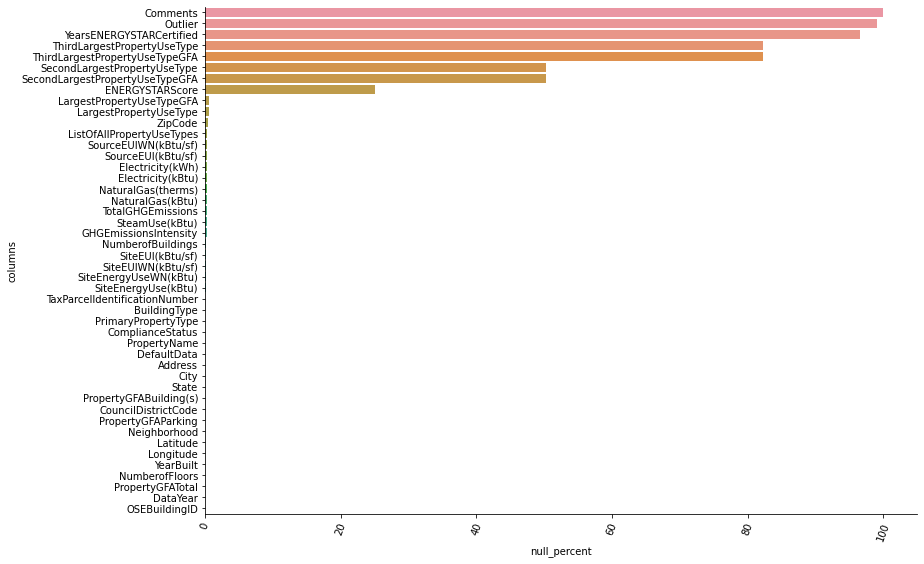

In [16]:
show_nulls(df)

## Duplicates

In [17]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3371    False
3372    False
3373    False
3374    False
3375    False
Length: 3376, dtype: bool

In [18]:
len(df)-len(df.drop_duplicates())

0

In [19]:
df.groupby(df.columns.tolist(),as_index=False).size()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,size


In [20]:
##df.groupby(['Longitude', 'Latitude'])['Crime type'].value_counts().to_frame('count')

## categories

In [21]:
df.select_dtypes(['category','object']).nunique()

BuildingType                        8
PrimaryPropertyType                24
PropertyName                     3362
Address                          3354
City                                1
State                               1
TaxParcelIdentificationNumber    3268
Neighborhood                       19
ListOfAllPropertyUseTypes         466
LargestPropertyUseType             56
SecondLargestPropertyUseType       50
ThirdLargestPropertyUseType        44
YearsENERGYSTARCertified           65
ComplianceStatus                    4
Outlier                             2
dtype: int64

In [22]:
df['ZipCode'].unique()

array([98101., 98121., 98104., 98154., 98118., 98105., 98112., 98125.,
       98109., 98070., 98108., 98199., 98115., 98107., 98144., 98103.,
       98119., 98136., 98122., 98126., 98133., 98146., 98033., 98106.,
       98111., 98134., 98117., 98116., 98191., 98164., 98195., 98185.,
       98181., 98102., 98168., 98155., 98006., 98124., 98053., 98012.,
       98013., 98028., 98178., 98114., 98127., 98165., 98011., 98198.,
       98113., 98040., 98204., 98177., 98020., 98272., 98145.,    nan])

In [23]:
df['Comments'].unique()

array([nan])

In [24]:
df['Comments'].nunique()

0

In [25]:
for column in df.columns:
    if df[column].nunique()<20:
        print('Colonne {}, valeurs uniques :\n{}\n'.format(column, df[column].unique()))
    else:
        print('Colonne {}, {} valeurs uniques'.format(column, df[column].nunique()))

Colonne OSEBuildingID, 3376 valeurs uniques
Colonne DataYear, valeurs uniques :
[2016]

Colonne BuildingType, valeurs uniques :
['NonResidential' 'Nonresidential COS' 'Multifamily MR (5-9)'
 'SPS-District K-12' 'Campus' 'Multifamily LR (1-4)'
 'Multifamily HR (10+)' 'Nonresidential WA']

Colonne PrimaryPropertyType, 24 valeurs uniques
Colonne PropertyName, 3362 valeurs uniques
Colonne Address, 3354 valeurs uniques
Colonne City, valeurs uniques :
['Seattle']

Colonne State, valeurs uniques :
['WA']

Colonne ZipCode, 55 valeurs uniques
Colonne TaxParcelIdentificationNumber, 3268 valeurs uniques
Colonne CouncilDistrictCode, valeurs uniques :
[7 3 2 4 5 6 1]

Colonne Neighborhood, valeurs uniques :
['DOWNTOWN' 'SOUTHEAST' 'NORTHEAST' 'EAST' 'Central' 'NORTH'
 'MAGNOLIA / QUEEN ANNE' 'LAKE UNION' 'GREATER DUWAMISH' 'BALLARD'
 'NORTHWEST' 'CENTRAL' 'SOUTHWEST' 'DELRIDGE' 'Ballard' 'North' 'Delridge'
 'Northwest' 'DELRIDGE NEIGHBORHOODS']

Colonne Latitude, 2876 valeurs uniques
Colonne Longit

# Retrait des colonnes inutiles

## garder uniquement batiments non-résidentiels

In [26]:
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'Multifamily MR (5-9)',
       'SPS-District K-12', 'Campus', 'Multifamily LR (1-4)',
       'Multifamily HR (10+)', 'Nonresidential WA'], dtype=object)

In [27]:
# get rows with BuildingType with 'Multifamily' prefix
# count code values with 200 prefix
df['BuildingType'].loc[df['BuildingType'].str.startswith('Multifamily')]

9       Multifamily MR (5-9)
165     Multifamily MR (5-9)
173     Multifamily MR (5-9)
188     Multifamily LR (1-4)
189     Multifamily MR (5-9)
                ...         
3353    Multifamily MR (5-9)
3354    Multifamily MR (5-9)
3355    Multifamily MR (5-9)
3357    Multifamily MR (5-9)
3358    Multifamily LR (1-4)
Name: BuildingType, Length: 1708, dtype: object

In [28]:
# remove "MultiFamily" related rows
df = df.loc[~df['BuildingType'].str.startswith('Multifamily')]

In [29]:
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'SPS-District K-12',
       'Campus', 'Nonresidential WA'], dtype=object)

## Colonnes inutiles

In [30]:
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


## Retrait des 'Outlier's


In [31]:
df.shape

(1668, 46)

In [32]:
df['Outlier'].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Outlier, dtype: object

In [33]:
df['Outlier'].value_counts()

Low outlier     15
High outlier     2
Name: Outlier, dtype: int64

In [34]:
df = df[df['Outlier'].isnull()]

In [35]:
df.shape

(1651, 46)

## TotalGHGEmissions : valeurs manquantes

Colonnes pertinentes comme cibles/target pour les 2 entraînements sujets de l'étude demandée.

description : https://data.seattle.gov/dataset/2016-Building-Energy-Benchmarking/2bpz-gwpy

emissions CO2 : 
- TotalGHGEmissions
- The total amount of greenhouse gas emissions, including carbon dioxide, methane, and nitrous oxide gases released into the atmosphere as a result of energy consumption at the property, measured in metric tons of carbon dioxide equivalent. 

consommation : 
- SiteEnergyUseWN(kBtu) / SiteEnergyUse(kBtu) => 1ère est une pred, à vérifier
- The annual amount of energy consumed by the property from all sources of energy, adjusted to what the property would have consumed during 30-year average weather conditions.

In [36]:
df['TotalGHGEmissions'].nunique()

1578

In [37]:
df['TotalGHGEmissions'].value_counts()

0.00      6
6.30      3
1.60      2
2.82      2
4.80      2
         ..
246.83    1
147.82    1
119.93    1
260.13    1
41.27     1
Name: TotalGHGEmissions, Length: 1578, dtype: int64

In [38]:
df.loc[df['TotalGHGEmissions'] == 0]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
28,34,2016,SPS-District K-12,K-12 School,Meany Building,301/300 21st Ave. E.,Seattle,WA,98112.0,0688000090,3,Central,47.62266,-122.30547,1955,1.0,1,126351,0,126351,K-12 School,K-12 School,126351.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,Missing Data,NaN,0.0,0.0
152,242,2016,SPS-District K-12,K-12 School,Olympic View Elementary,504 N.E. 95th St.,Seattle,WA,98115.0,5100404840,5,NORTH,47.69823,-122.32126,1989,1.0,2,52792,0,52792,K-12 School,K-12 School,55480.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,Missing Data,NaN,0.0,0.0
304,435,2016,NonResidential,Other,Washington State Convention Center,705 Pike St,Seattle,WA,98101.0,1978200105,7,DOWNTOWN,47.61195,-122.33167,1990,1.0,6,1400000,0,1400000,"Convention Center, Parking",Convention Center,1072000.0,Parking,686750.0,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,Non-Compliant,NaN,0.0,0.0
513,700,2016,NonResidential,Supermarket / Grocery Store,IUC- Whole Foods Interbay,2001 15th Avenue West,Seattle,WA,98119.0,7666201460,7,MAGNOLIA / QUEEN ANNE,47.63718,-122.37734,2008,1.0,1,57176,0,57176,"Personal Services (Health/Beauty, Dry Cleaning, etc), Retail Store, Supermarket/Grocery Store",Supermarket/Grocery Store,39500.0,Retail Store,15000.0,"Personal Services (Health/Beauty, Dry Cleaning, etc)",5500.0,NaN,31.0,208.800003,214.100006,0.0,0.0,12525174.0,12843856.0,0.0,0.0,0.0,0.0,0.0,False,NaN,Compliant,NaN,0.0,0.0
746,19776,2016,NonResidential,Other,Welcome Home Society - PriceCo,13537 Aurora Ave N,Seattle,WA,98133.0,0164000020,5,NORTHWEST,47.72777,-122.34503,2002,1.0,1,29924,0,29924,Other - Education,Other - Education,29924.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,Missing Data,NaN,0.0,0.0
1361,21616,2016,SPS-District K-12,K-12 School,Olympic Hills Elementary,13018 20th Ave. N.E.,Seattle,WA,98125.0,2126049041,5,NORTH,47.72369,-122.30676,1954,1.0,1,42292,0,42292,K-12 School,K-12 School,43188.0,NaN,NaN,NaN,NaN,NaN,100.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,NaN,Error - Correct Default Data,NaN,0.0,0.0


In [39]:
filter_list = [0]

In [40]:
df = df.loc[~df['TotalGHGEmissions'].isin(filter_list)]

In [41]:
df.shape

(1645, 46)

In [42]:
df

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1.0,1,12294,0,12294,Office,Office,12294.0,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,16000,0,16000,Other - Recreation,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1.0,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recreation, Swimming Pool",Other - Recreation,7583.0,Fitness Center/Health Club/Gy

## Retrait des colonnes non-utilisables / redondantes

In [43]:
cols_to_drop = [
    'OSEBuildingID', # inutilisé
    'City', #une seule valeur unique
    'State', #une seule valeur unique
    'PropertyName', #inutilisé
    'TaxParcelIdentificationNumber', #inutilisé
    'Address', #redondant avec latitude / longitude
    'ZipCode', #redondant avec latitude / longitude
    #'Neighborhood',
    'Comments', # 100% de données manquantes
    'Outlier', # 99% de données manquantes, a permis de retirer précedemment les lignes libellées "outlier"
    'YearsENERGYSTARCertified' #96.5% de données manquantes
]

In [44]:
df.shape

(1645, 46)

In [45]:
cols_to_drop += [
    'SiteEUI(kBtu/sf)',
    'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUse(kBtu)',
    #'SiteEnergyUseWN(kBtu)', -- comporte une prédiction
    'SteamUse(kBtu)',
    'Electricity(kWh)',
    'Electricity(kBtu)',
    'NaturalGas(therms)',
    'NaturalGas(kBtu)',
    'GHGEmissionsIntensity'
]

In [46]:
df['SiteEnergyUseWN(kBtu)'].nunique()

1622

In [47]:
df['SiteEnergyUseWN(kBtu)'].value_counts()

0.000000e+00    20
2.127889e+06     2
7.456910e+06     1
2.842820e+06     1
1.672466e+06     1
                ..
2.533838e+06     1
4.040139e+06     1
3.904791e+06     1
4.634330e+07     1
1.293722e+06     1
Name: SiteEnergyUseWN(kBtu), Length: 1622, dtype: int64

In [48]:
cols_to_drop

['OSEBuildingID',
 'City',
 'State',
 'PropertyName',
 'TaxParcelIdentificationNumber',
 'Address',
 'ZipCode',
 'Comments',
 'Outlier',
 'YearsENERGYSTARCertified',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'GHGEmissionsIntensity']

In [49]:
df.shape

(1645, 46)

In [50]:
df.drop(cols_to_drop, axis=1, inplace=True)

In [51]:
df.shape

(1645, 25)

                                                         columns  count  \
ThirdLargestPropertyUseTypeGFA    ThirdLargestPropertyUseTypeGFA   1295   
ThirdLargestPropertyUseType          ThirdLargestPropertyUseType   1295   
SecondLargestPropertyUseTypeGFA  SecondLargestPropertyUseTypeGFA    799   
SecondLargestPropertyUseType        SecondLargestPropertyUseType    799   
ENERGYSTARScore                                  ENERGYSTARScore    564   
LargestPropertyUseTypeGFA              LargestPropertyUseTypeGFA      6   
LargestPropertyUseType                    LargestPropertyUseType      6   
SiteEnergyUseWN(kBtu)                      SiteEnergyUseWN(kBtu)      3   
TotalGHGEmissions                              TotalGHGEmissions      2   
ListOfAllPropertyUseTypes              ListOfAllPropertyUseTypes      2   
NumberofBuildings                              NumberofBuildings      2   
ComplianceStatus                                ComplianceStatus      0   
DefaultData              

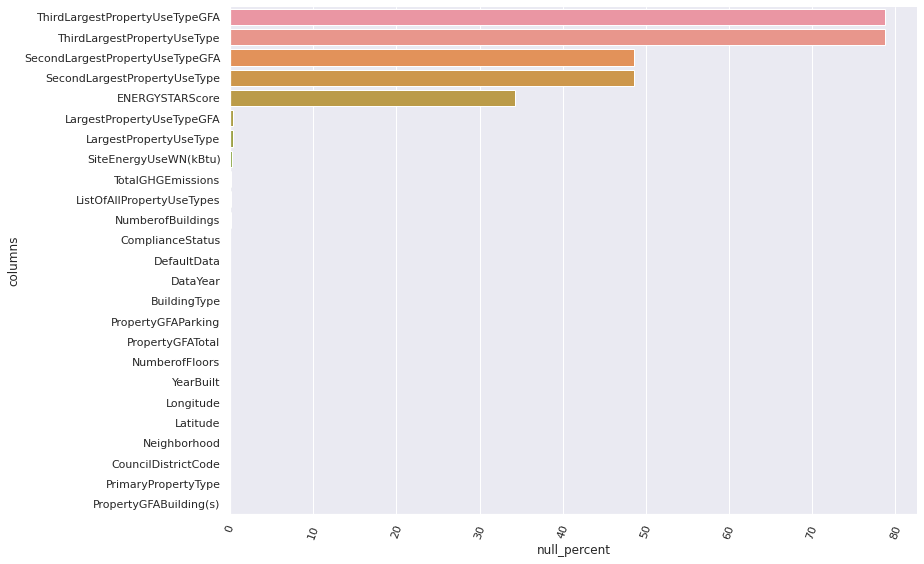

In [52]:
show_nulls(df)

In [53]:
### remplir vides si besoin

In [54]:
#df[df.columns[df.isnull().any()]].isnull().sum()

In [55]:
#df[df.columns[df.isnull().any()]].isnull().sum() * 100 / df.shape[0]

In [56]:
df['ThirdLargestPropertyUseType'].unique()

array([nan, 'Restaurant', 'Swimming Pool', 'Data Center', 'Office',
       'Retail Store', 'Other - Entertainment/Public Assembly',
       'Non-Refrigerated Warehouse', 'Other', 'Distribution Center',
       'Food Service', 'Other - Services', 'Medical Office', 'Parking',
       'Other - Utility', 'K-12 School', 'Fitness Center/Health Club/Gym',
       'Social/Meeting Hall', 'Pre-school/Daycare',
       'Convenience Store without Gas Station', 'Financial Office',
       'Other - Restaurant/Bar', 'Other - Education',
       'Multifamily Housing', 'Laboratory', 'Bank Branch', 'Hotel',
       'Other - Recreation',
       'Personal Services (Health/Beauty, Dry Cleaning, etc)',
       'Self-Storage Facility', 'Other - Technology/Science',
       'Refrigerated Warehouse', 'Bar/Nightclub',
       'Manufacturing/Industrial Plant', 'Other/Specialty Hospital',
       'Fast Food Restaurant', 'Worship Facility',
       'Supermarket/Grocery Store', 'Strip Mall', 'Vocational School'],
      dtype=ob

In [57]:
df['ThirdLargestPropertyUseType'].nunique()

39

In [58]:
df['SecondLargestPropertyUseType'].unique()

array([nan, 'Parking', 'Office', 'Restaurant', 'K-12 School',
       'Laboratory', 'Refrigerated Warehouse',
       'Non-Refrigerated Warehouse', 'Other - Education',
       'Vocational School', 'Retail Store',
       'Personal Services (Health/Beauty, Dry Cleaning, etc)',
       'Other - Entertainment/Public Assembly', 'Data Center',
       'Swimming Pool', 'Other', 'Courthouse', 'Residence Hall/Dormitory',
       'Distribution Center', 'Self-Storage Facility', 'Other - Services',
       'Movie Theater', 'Supermarket/Grocery Store', 'Medical Office',
       'Other - Recreation', 'Convenience Store without Gas Station',
       'Performing Arts', 'College/University', 'Other - Restaurant/Bar',
       'Adult Education', 'Enclosed Mall', 'Multifamily Housing',
       'Bar/Nightclub', 'Financial Office',
       'Repair Services (Vehicle, Shoe, Locksmith, etc)',
       'Manufacturing/Industrial Plant', 'Other - Lodging/Residential',
       'Bank Branch', 'Fitness Center/Health Club/Gym', 'H

In [59]:
df['SecondLargestPropertyUseType'].nunique()

47

In [60]:
df['ENERGYSTARScore'].unique()

array([ 60.,  61.,  43.,  56.,  75.,  nan,  27.,  30.,  36.,  48.,  58.,
        35.,  31.,  39.,  76.,  95.,  84.,  57.,  29.,   8.,  97.,  88.,
        83.,  67.,  78.,  14.,  71.,  63.,  98.,  99.,  86.,  80.,  81.,
        94.,  54.,   1.,  74.,  96.,  37.,  91.,  93.,  68.,  53.,  34.,
       100.,  89.,  92.,  90.,  79.,  21.,  10.,  72.,  87.,  70.,  64.,
        49.,  62.,  46.,  42.,  77.,  20.,  85.,  66.,  69.,  28.,  65.,
         3.,  45.,   2.,  55.,  25.,   6.,  59.,  19.,   7.,   5.,  23.,
        38.,  73.,  33.,  26.,  41.,  32.,  82.,  15.,  16.,  50.,  12.,
        51.,  13.,  11.,  47.,  18.,  24.,  17.,  52.,  44.,   4.,  40.,
        22.,   9.])

In [61]:
#df['ENERGYSTARScore'].value_counts()

In [62]:
### check valeurs erronnées / outliers (negatives ?)

In [63]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1645 entries, 0 to 3375
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1645 non-null   int64  
 1   BuildingType                     1645 non-null   object 
 2   PrimaryPropertyType              1645 non-null   object 
 3   CouncilDistrictCode              1645 non-null   int64  
 4   Neighborhood                     1645 non-null   object 
 5   Latitude                         1645 non-null   float64
 6   Longitude                        1645 non-null   float64
 7   YearBuilt                        1645 non-null   int64  
 8   NumberofBuildings                1643 non-null   float64
 9   NumberofFloors                   1645 non-null   int64  
 10  PropertyGFATotal                 1645 non-null   int64  
 11  PropertyGFAParking               1645 non-null   int64  
 12  PropertyGFABuilding(

In [64]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['Latitude', 'Longitude', 'NumberofBuildings',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore',
       'SiteEnergyUseWN(kBtu)', 'TotalGHGEmissions'],
      dtype='object')

In [65]:
def UVA_numeric2(data, i):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''
  # calculating descriptives of variable
  mini = data[i].min()
  maxi = data[i].max()
  ran = data[i].max()-data[i].min()
  mean = data[i].mean()
  median = data[i].median()
  st_dev = data[i].std()
  skew = data[i].skew()
  kurt = data[i].kurtosis()

  # calculating points of standard deviation
  points = mean-st_dev, mean+st_dev

  #Plotting the variable with every information
  sns.kdeplot(data[i], shade=True)
  sns.lineplot(points, [0,0], color = 'black', label = "std_dev")
  sns.scatterplot([mini,maxi], [0,0], color = 'orange', label = "min/max")
  sns.scatterplot([mean], [0], color = 'red', label = "mean")
  sns.scatterplot([median], [0], color = 'blue', label = "median")
  plt.xlabel('{}'.format(i), fontsize = 20)
  plt.ylabel('density')
  plt.title('std_dev = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((round(points[0],2),round(points[1],2)),
                                                                                                   round(kurt,2),
                                                                                                   round(skew,2),
                                                                                                   (round(mini,2),round(maxi,2),round(ran,2)),
                                                                                                   round(mean,2),
                                                                                                   round(median,2)))

In [66]:
# afficher détail Boxplot / UVA_num pour chaque indicateur par ligne

def UVA_num_plus(df, indicators_list):
  
    for i in indicators_list:
        plt.figure(figsize = (15, 20))
        df_indic = df[i]

        plt.subplot(5,2,1)
        sns.boxplot(y=df_indic)
        plt.xlabel(f'{i}', fontsize = 20)


        plt.subplot(5,2,2)
        UVA_numeric2(df, i)


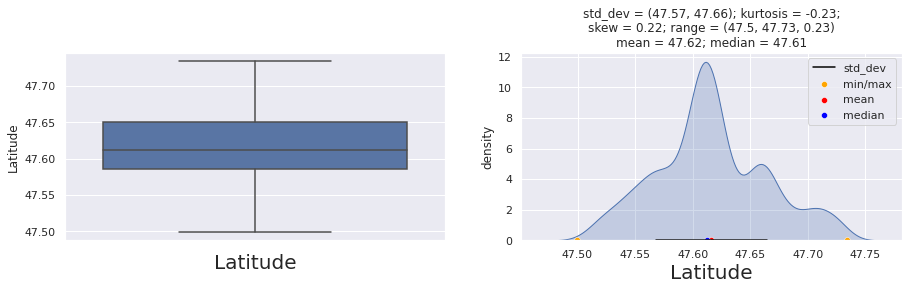

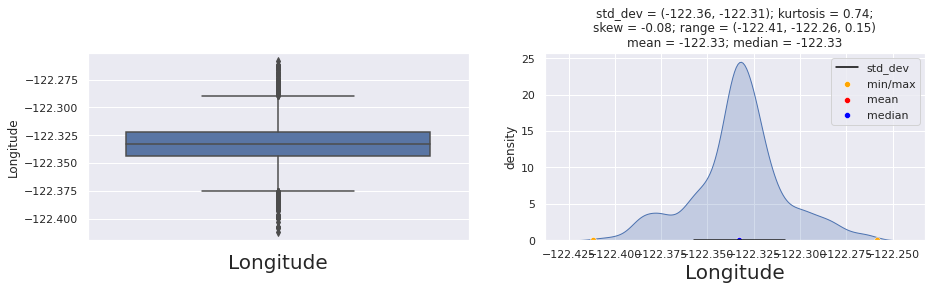

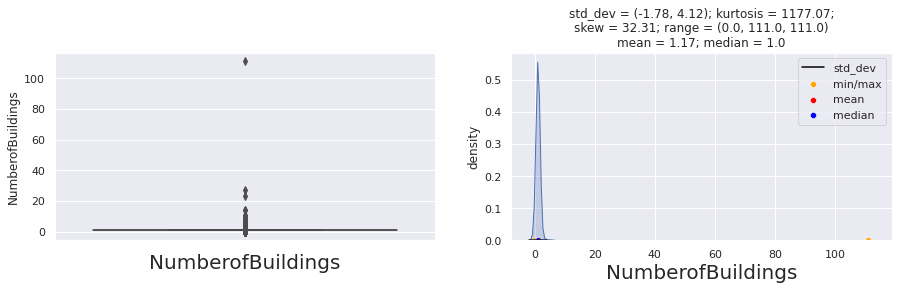

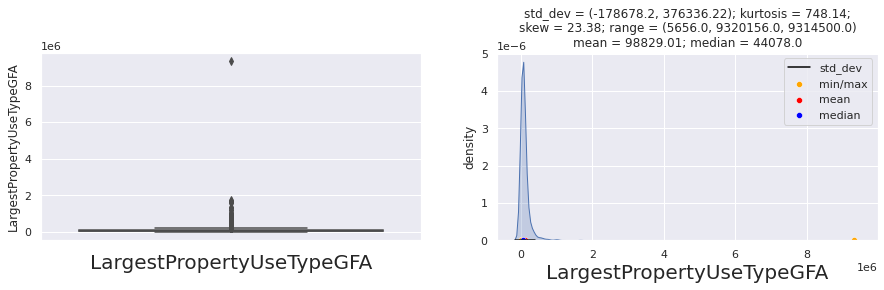

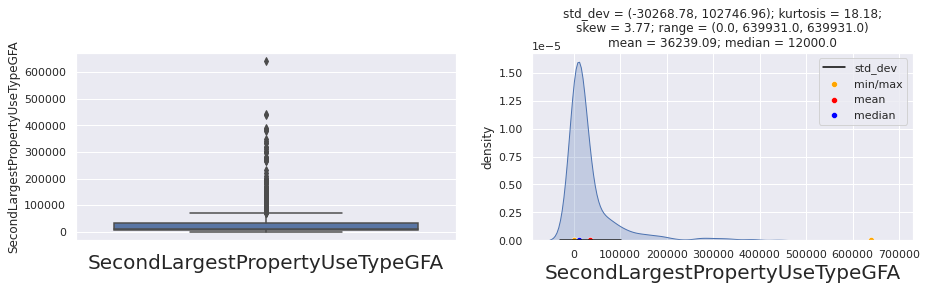

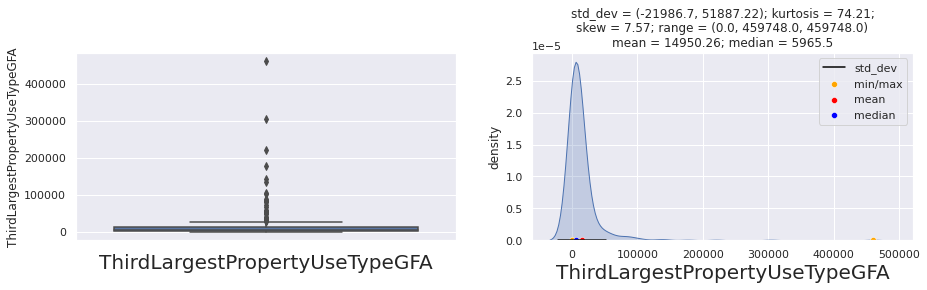

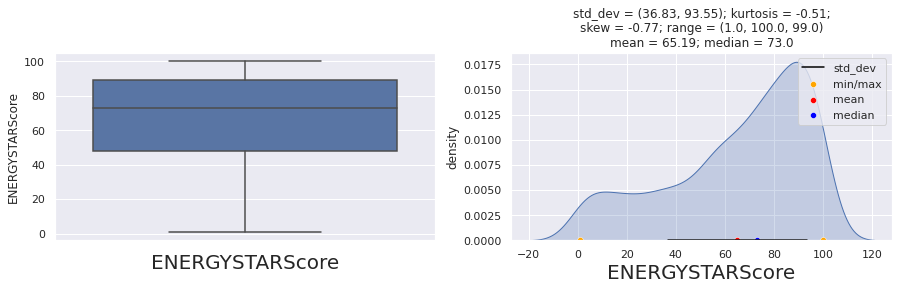

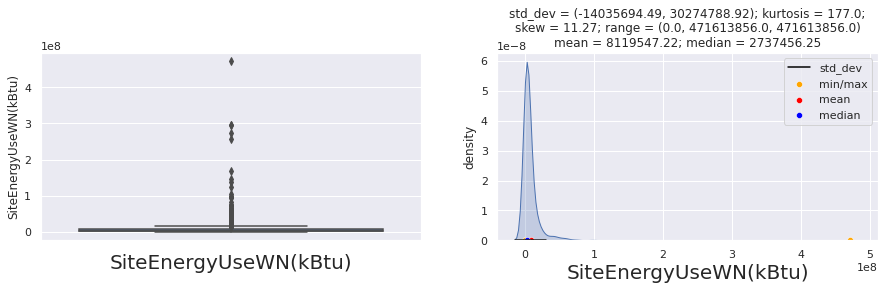

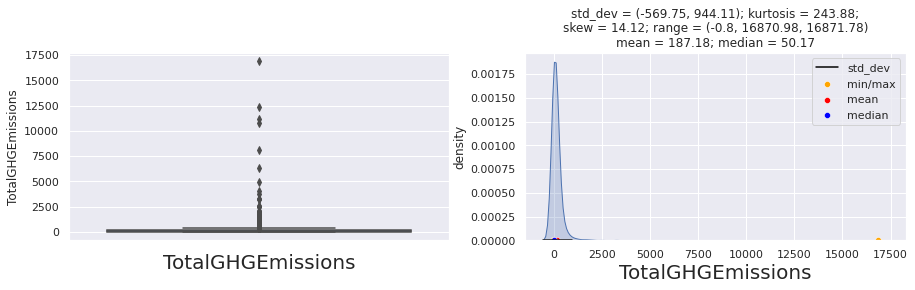

In [67]:
UVA_num_plus(df, num_cols)

In [68]:
num_cols

Index(['Latitude', 'Longitude', 'NumberofBuildings',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore',
       'SiteEnergyUseWN(kBtu)', 'TotalGHGEmissions'],
      dtype='object')

In [69]:
df['NumberofBuildings'].value_counts()

1.0      1539
0.0        52
2.0        14
3.0        12
5.0         7
4.0         4
6.0         4
14.0        2
8.0         2
27.0        1
11.0        1
9.0         1
7.0         1
23.0        1
10.0        1
111.0       1
Name: NumberofBuildings, dtype: int64

In [70]:
# si volonté de réduire skewness => faire log
# bonus : faire log pour comparer (s'approche de la distribution normale)
# skewness négative => check doc

In [71]:
### scatter coordonnées 

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


<AxesSubplot:xlabel='Longitude', ylabel='Latitude'>

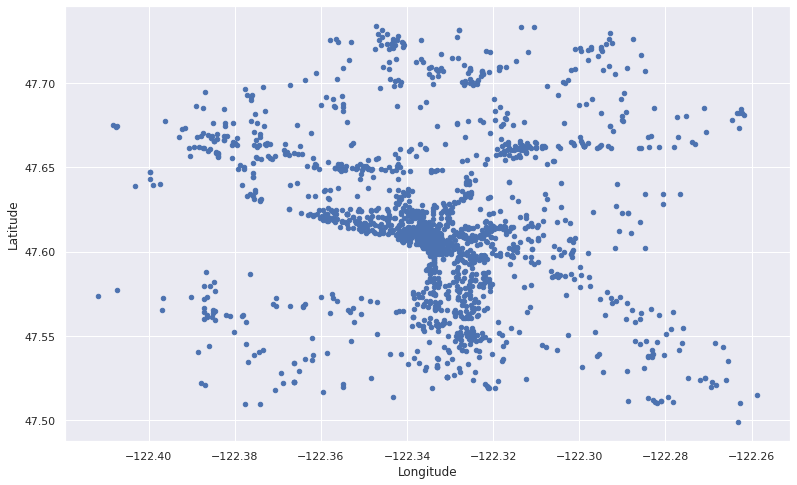

In [72]:
df.plot(x="Longitude", 
        y="Latitude", 
        kind="scatter", 
        #c="brightness",
        #colormap="YlOrRd"
       )

In [73]:
countries = gpd.read_file(
               gpd.datasets.get_path("naturalearth_lowres"))
#countries.head()

In [74]:
#countries.plot(color="lightgrey")

In [75]:
#countries.loc[countries.iso_a3 == 'USA'].plot(color="lightgrey")

In [76]:
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))

In [77]:
gdf.head()

,DataYear,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,geometry
0,2016,NonResidential,Hotel,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,60.0,7456910.0,False,Compliant,249.98,POINT (-122.33799 47.61220)
1,2016,NonResidential,Hotel,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,61.0,8664479.0,False,Compliant,295.86,POINT (-122.33393 47.61317)
2,2016,NonResidential,Hotel,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,43.0,73937112.0,False,Compliant,2089.28,POINT (-122.33810 47.61393)
3,2016,NonResidential,Hotel,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,56.0,6946800.5,False,Compliant,286.43,POINT (-122.33664 47.61412)
4,2016,NonResidential,Hotel,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,75.0,14656503.0,False,Compliant,505.01,POINT (-122.34047 47.61375)


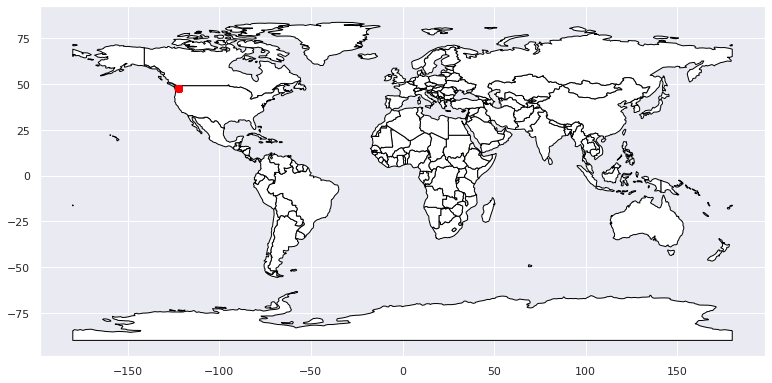

In [78]:
ax = countries.plot(
    color='white', edgecolor='black')

# plot``GeoDataFrame``.
gdf.plot(ax=ax, color='red')

plt.show()

In [79]:
mean_lat = df['Latitude'].describe()['mean']
mean_lat

47.6160101153617

In [80]:
mean_lon = df['Longitude'].describe()['mean']
mean_lon

-122.33293165860182

In [81]:
#place_name = 'Seattle, USA'
#tags = {'building': True}
#area = ox.geometries.geometries_from_place(place_name, tags)
#area.plot()

In [82]:
map = folium.Map(location=[mean_lat, mean_lon], zoom_start=11)

In [83]:
locations = df[['Latitude', 'Longitude']]
locationlist = locations.values.tolist()

In [84]:
for coord in locationlist:
    folium.Marker(
            location=[ coord[0], coord[1] ], 
            fill_color='#43d9de', radius=8).add_to(map)

map.save( 'map_s.html')

In [85]:
map

In [86]:
### avec coordonnées vérifier existence de quartiers / groupes

In [87]:
df.columns

Index(['DataYear', 'BuildingType', 'PrimaryPropertyType',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore',
       'SiteEnergyUseWN(kBtu)', 'DefaultData', 'ComplianceStatus',
       'TotalGHGEmissions', 'geometry'],
      dtype='object')

In [88]:
## pb referent entreprise => student success manager
## remplir questionnaire fin de mentorat (mail)

In [89]:
#df['DataYear'].value_counts()

In [90]:
### parkings ?

In [91]:
### années de construction / influence sur autres params ?
## (heatmap de seaborn)

In [92]:
### isoler var num et var cat
### normaliser num
### transformer var cat (OHE ou ordinal)


In [93]:
### autres ?

In [94]:
# 3 preds différentes, comparer avec même score (RMSE)

In [95]:
## essayer assembliste / random forest / svr / linearregression 
## check doc scikitlab regresseurs
## /!\ ne pas oublier normalisation